# Sticky-strike PCA factor model of vol surface moves

The headline risk model works in **sticky-strike** coordinates: each pillar (τ, m) tracks
the fixed strike K = m% of the *previous* close, so its daily change samples the new
surface at moneyness m·S₀/S₁ (with the same bicubic interpolant pricing uses) — the
surface move **plus** the smile slide at fixed TTM, term roll excluded. The model targets
the book's **fixed-strike vol P&L ex roll** (attribution `vol − vol_roll`), and its
exposures pair with the plain BS delta. Why these coordinates beat modeling the
moneyness-surface move separately (with slide handed over from the equity side) is shown
in `sticky_strike.ipynb`.

The book's vega is bucketed onto the pillar grid (8 TTMs × 13 moneyness) via its
interpolation weights — the bicubic lookup is linear in the pillar vols, so the
cardinal-basis weights are exact. PCA is fit on the daily sticky-strike pillar changes
**weighted by the book's average absolute dollar vega per pillar**, so factor capacity is
allocated by P&L relevance rather than raw surface variance (far-OTM short-dated smile
noise the book barely prices off is ignored).

- Exposure to factor k: \$E_k = (\text{bucket vega}/w)\cdot L_k\$
- Daily factor movement (score): \$f_k = L_k\cdot((\Delta\sigma-\mu)\circ w)\$
- Vol P&L estimate with K factors: \$\text{bucket vega}\cdot\mu + \sum_{k\le K}E_k f_k\$

This notebook illustrates the factor shapes, their history, the estimate quality against
the fixed-strike target, and the roll-carry split that defines the target.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

from vol_pca import load_surfaces, simulate_book, fit_pca, factor_vega_estimates, estimate_metrics
from vol_pca.factors import sticky_strike_dsigma
from vol_pca.attribution import independent_attribution
from vol_pca.surface import TTM_PILLARS, MONEYNESS

PC_C = ["#2a78d6", "#eb6834", "#1baf7a"]          # PC1/2/3 (all-pairs safe trio)
INK, MUT = "#0b0b0b", "#898781"
DIV_CMAP = LinearSegmentedColormap.from_list("bwr_soft", ["#2a78d6", "#f0efec", "#e34948"])
plt.rcParams.update({
    "figure.facecolor": "#fcfcfb", "axes.facecolor": "#fcfcfb",
    "axes.edgecolor": "#c3c2b7", "axes.labelcolor": "#52514e",
    "axes.grid": True, "grid.color": "#e1e0d9", "grid.linewidth": 0.8,
    "xtick.color": "#898781", "ytick.color": "#898781",
    "text.color": "#0b0b0b", "axes.spines.top": False, "axes.spines.right": False,
    "font.size": 10, "figure.figsize": (10, 4.2), "figure.dpi": 110,
    "legend.frameon": False,
})
TTM_LBL = ["1M", "2M", "3M", "4M", "6M", "8M", "10M", "12M"]
MON_LBL = [str(int(m)) for m in MONEYNESS]

sd = load_surfaces("SPX_volSurface 2.csv")
book, bucket_vega, _ = simulate_book(sd)
dsigma = sticky_strike_dsigma(sd)              # sticky-strike, bicubic sampling
attr, _ = independent_attribution(sd)
normal = (book["gap_days"] <= 7).to_numpy()

vega_w = np.abs(bucket_vega[normal]).mean(axis=0)
model = fit_pca(dsigma, fit_mask=normal, weights=vega_w)

# sign convention: the largest-|loading| pillar of each factor is positive
for i in range(6):
    pat = model.components[i] / model.weights
    if pat[np.argmax(np.abs(pat))] < 0:
        model.components[i] *= -1

ks = [1, 2, 3, 5, 10, model.n_components]
estimates, exposures, scores = factor_vega_estimates(bucket_vega, dsigma, model, ks)
target = (attr["vol"] - attr["vol_roll"]).to_numpy()   # fixed-strike vol P&L ex roll
print(f"{len(book)} P&L days; grid {len(TTM_PILLARS)} TTMs x {len(MONEYNESS)} moneyness "
      f"= {dsigma.shape[1]} pillars")
print(f"target: fixed-strike vol P&L ex roll, daily std ${target[normal].std():,.0f}")

3140 P&L days; grid 8 TTMs x 13 moneyness = 104 pillars
target: fixed-strike vol P&L ex roll, daily std $69,712


## Factor shapes

Each panel shows the surface move produced by a **+1 standard deviation** move of that
factor, in vol points, on the TTM × moneyness grid. PC1 is the level factor, with a much
flatter smile profile than its moneyness-coordinates counterpart (the skewed part of the
level move is what the slide cancels); PC2 reshapes the short end and the wings, PC3 the
call wing.

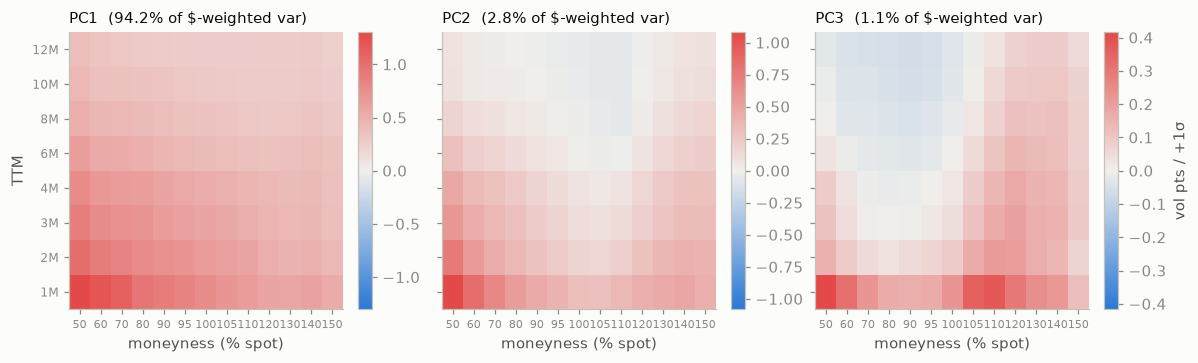

In [2]:
nt, nm = len(TTM_PILLARS), len(MONEYNESS)
fig, axes = plt.subplots(1, 3, figsize=(11, 3.4), sharey=True)
for i, ax in enumerate(axes):
    pat = (scores[normal][:, i].std() * model.components[i] / model.weights * 100).reshape(nt, nm)
    vmax = np.abs(pat).max()
    im = ax.imshow(pat, origin="lower", aspect="auto", cmap=DIV_CMAP, vmin=-vmax, vmax=vmax)
    ax.set_xticks(range(nm), MON_LBL, fontsize=7)
    ax.set_yticks(range(nt), TTM_LBL, fontsize=8)
    ax.set_title(f"PC{i+1}  ({model.evr[i]:.1%} of $-weighted var)", loc="left", fontsize=10)
    ax.set_xlabel("moneyness (% spot)")
    ax.grid(False)
    fig.colorbar(im, ax=ax, label="vol pts / +1σ" if i == 2 else None, fraction=0.046)
axes[0].set_ylabel("TTM")
plt.tight_layout(); plt.show()

In [3]:
def slices(i):
    pat = (scores[normal][:, i].std() * model.components[i] / model.weights * 100).reshape(nt, nm)
    return pat[:, list(MONEYNESS).index(100.0)], pat[list(TTM_PILLARS).index(0.5)]

atm = pd.DataFrame({f"PC{i+1}": slices(i)[0] for i in range(3)}, index=TTM_LBL)
smile = pd.DataFrame({f"PC{i+1}": slices(i)[1] for i in range(3)}, index=MON_LBL)
print("ATM (100%) term structure, vol pts per +1σ factor move:")
print(atm.round(3).to_string())
print("\n6M smile, vol pts per +1σ factor move:")
print(smile.round(3).to_string())

ATM (100%) term structure, vol pts per +1σ factor move:
       PC1    PC2    PC3
1M   0.767  0.307  0.225
2M   0.649  0.170  0.090
3M   0.580  0.115  0.040
4M   0.512  0.074  0.022
6M   0.397  0.009  0.001
8M   0.338 -0.018 -0.018
10M  0.296 -0.037 -0.030
12M  0.262 -0.045 -0.035

6M smile, vol pts per +1σ factor move:
       PC1    PC2    PC3
50   0.625  0.304  0.029
60   0.536  0.201 -0.008
70   0.521  0.167 -0.025
80   0.493  0.132 -0.027
90   0.455  0.084 -0.029
95   0.423  0.053 -0.021
100  0.397  0.009  0.001
105  0.377 -0.019  0.046
110  0.360 -0.015  0.101
120  0.350  0.072  0.144
130  0.358  0.159  0.130
140  0.386  0.210  0.123
150  0.348  0.219  0.078


## Explained variance and estimate quality

Left: share of dollar-weighted surface variance per factor. Right: how well the factor
estimate reproduces the **fixed-strike vol P&L ex roll** day by day — the all-factor row
is the linear bucketed-vega limit (what remains is a small off-pillar sampling error plus
vega convexity on the net move), and the correlation-PCA row shows what vega weighting
buys at k=3.

In [4]:
evr = pd.DataFrame({"EVR": model.evr[:8], "cumulative": model.evr[:8].cumsum()},
                   index=[f"PC{i+1}" for i in range(8)])
print((evr * 100).round(1).to_string(), "\n")

est_named = {f"vega-PCA k={k}" if k < model.n_components else "all factors (linear est)": v
             for k, v in estimates.items()}
corr3, _, _ = factor_vega_estimates(
    bucket_vega, dsigma, fit_pca(dsigma, fit_mask=normal, weights="corr"), [3])
est_named["corr-PCA k=3"] = corr3[3]
print(estimate_metrics(target, est_named, mask=normal).round(4).to_string())

      EVR  cumulative
PC1  94.2        94.2
PC2   2.8        97.0
PC3   1.1        98.1
PC4   0.4        98.5
PC5   0.3        98.8
PC6   0.3        99.1
PC7   0.2        99.3
PC8   0.1        99.4 

                              r2    corr        rmse
estimate                                            
vega-PCA k=1              0.5422  0.7552  47205.3019
vega-PCA k=2              0.6353  0.8025  42150.3831
vega-PCA k=3              0.8108  0.9028  30366.7878
vega-PCA k=5              0.8559  0.9279  26470.8198
vega-PCA k=10             0.9343  0.9677  17872.5377
all factors (linear est)  0.9852  0.9928   8500.1221
corr-PCA k=3              0.6464  0.8057  41499.4795


## Factor history

Cumulative factor scores (in units of their own daily std). PC1 reads as the fixed-strike
vol history: grinding down in calm years, spiking in Feb 2018, March 2020, 2022, April
2025 — and, unlike the moneyness-coordinates level factor, it is nearly orthogonal to
spot returns day to day (see `sticky_strike.ipynb`).

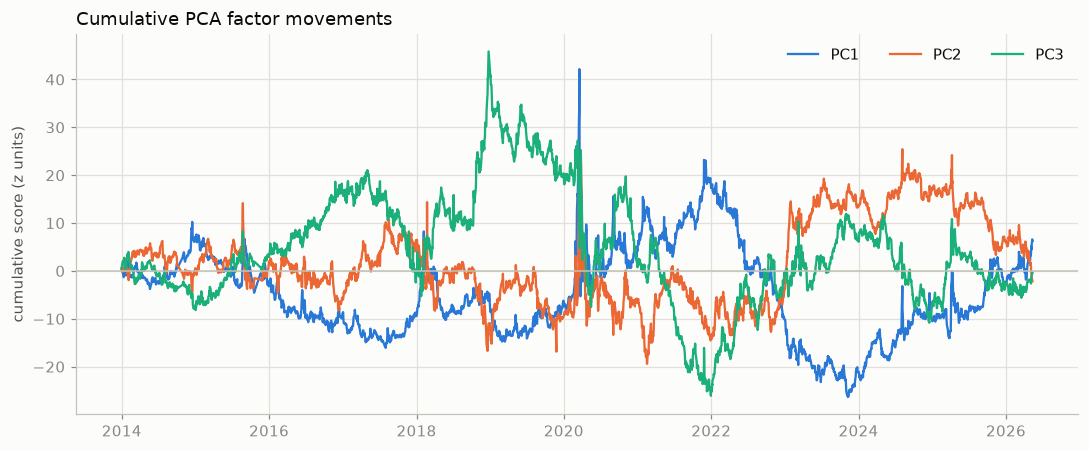

In [5]:
fig, ax = plt.subplots()
for i in range(3):
    z = scores[:, i] / scores[normal][:, i].std()
    ax.plot(book.index, np.cumsum(z), color=PC_C[i], lw=1.5, label=f"PC{i+1}")
ax.axhline(0, color="#c3c2b7", lw=1)
ax.set_ylabel("cumulative score (z units)")
ax.set_title("Cumulative PCA factor movements", loc="left")
ax.legend(loc="upper right", ncols=3)
plt.tight_layout(); plt.show()

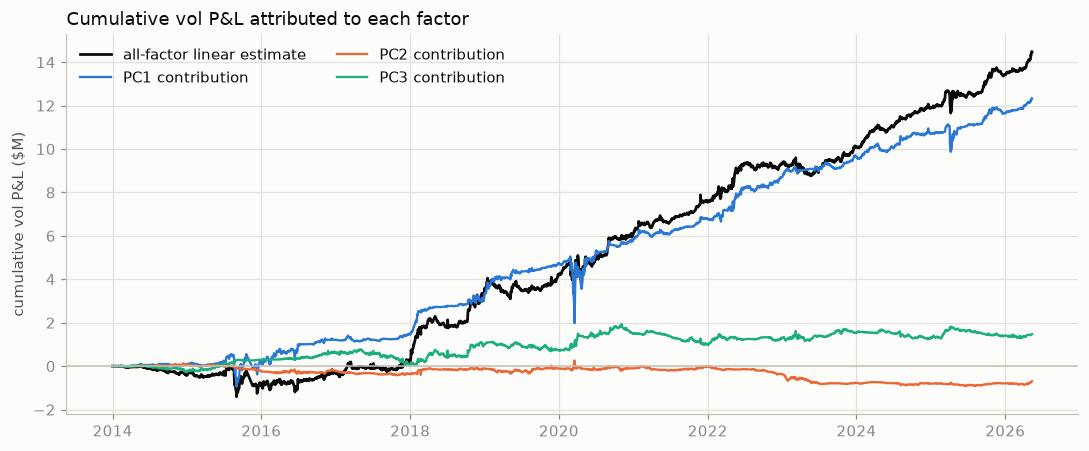

In [6]:
fig, ax = plt.subplots()
lin_total = (bucket_vega * dsigma).sum(axis=1)
ax.plot(book.index, lin_total.cumsum() / 1e6, color=INK, lw=1.8, label="all-factor linear estimate")
for i in range(3):
    contrib = exposures[:, i] * scores[:, i]
    ax.plot(book.index, contrib.cumsum() / 1e6, color=PC_C[i], lw=1.5, label=f"PC{i+1} contribution")
ax.axhline(0, color="#c3c2b7", lw=1)
ax.set_ylabel("cumulative vol P&L ($M)")
ax.set_title("Cumulative vol P&L attributed to each factor", loc="left")
ax.legend(loc="upper left", ncols=2)
plt.tight_layout(); plt.show()

## Daily factor estimate vs the fixed-strike vol target

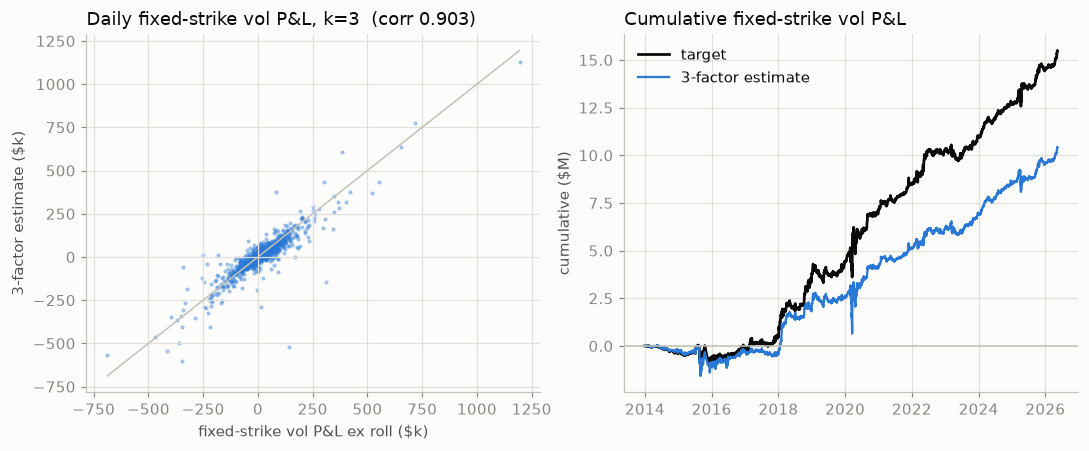

In [7]:
est3 = estimates[3]
fig, axes = plt.subplots(1, 2, figsize=(10, 4.2))
lim = np.array([target[normal].min(), target[normal].max()]) / 1e3
axes[0].plot(lim, lim, color="#c3c2b7", lw=1)
axes[0].scatter(target[normal] / 1e3, est3[normal] / 1e3, s=7, color=PC_C[0], alpha=0.45, lw=0)
c = np.corrcoef(target[normal], est3[normal])[0, 1]
axes[0].set_xlabel("fixed-strike vol P&L ex roll ($k)")
axes[0].set_ylabel("3-factor estimate ($k)")
axes[0].set_title(f"Daily fixed-strike vol P&L, k=3  (corr {c:.3f})", loc="left")

axes[1].plot(book.index, np.cumsum(target) / 1e6, color=INK, lw=1.8, label="target")
axes[1].plot(book.index, np.cumsum(est3) / 1e6, color=PC_C[0], lw=1.5, label="3-factor estimate")
axes[1].axhline(0, color="#c3c2b7", lw=1)
axes[1].set_ylabel("cumulative ($M)")
axes[1].set_title("Cumulative fixed-strike vol P&L", loc="left")
axes[1].legend(loc="upper left")
plt.tight_layout(); plt.show()

## The target and the roll carry

The attribution `vol` component is the option's **own** implied-vol input change (new
TTM, new moneyness) — it contains the fixed-strike surface-and-slide move *and* the
term-structure roll. The factor model targets

$$\text{target} \;=\; \text{vol} - \text{vol\_roll}$$

The roll is excluded because it is deterministic carry, not risk: `vol_carry_ex`
computes the same roll on the *previous close's* surface — before the day happens — and
matches the realized roll almost exactly, so it belongs in a carry forecast, not in the
factor model. (In moneyness coordinates the target would further split into a large
surface move and a large offsetting smile slide; that decomposition, and why we model
the net move directly instead, is `sticky_strike.ipynb`.)

In [8]:
va = pd.DataFrame({
    "vol": attr["vol"],
    "vol_ex_roll (target)": attr["vol"] - attr["vol_roll"],
    "vol_roll": attr["vol_roll"],
    "vol_carry_ex": attr["vol_carry_ex"],
})
t = va.loc[normal]
summ = pd.DataFrame({"total ($M)": va.sum() / 1e6,
                     "daily mean ($k)": t.mean() / 1e3,
                     "daily std ($k)": t.std() / 1e3})
print(summ.round(2).to_string())

print(f"\nrealized roll vs ex-ante carry : corr "
      f"{np.corrcoef(t['vol_roll'], t['vol_carry_ex'])[0, 1]:.4f}, "
      f"difference std {(t['vol_roll'] - t['vol_carry_ex']).std() / 1e3:.1f} $k/day")

                      total ($M)  daily mean ($k)  daily std ($k)
vol                        -3.12            -0.77           70.07
vol_ex_roll (target)       15.48             5.17           69.72
vol_roll                  -18.60            -5.94            5.86
vol_carry_ex              -18.71            -5.97            5.86

realized roll vs ex-ante carry : corr 0.9755, difference std 1.3 $k/day


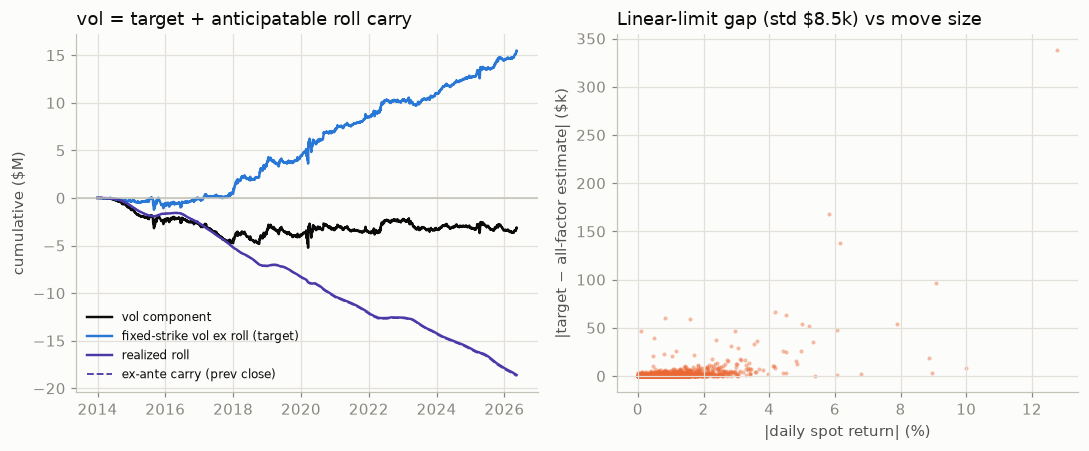

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4.2))
axes[0].plot(attr.index, va["vol"].cumsum() / 1e6, color=INK, lw=1.6, label="vol component")
axes[0].plot(attr.index, va["vol_ex_roll (target)"].cumsum() / 1e6, color=PC_C[0], lw=1.6,
             label="fixed-strike vol ex roll (target)")
axes[0].plot(attr.index, va["vol_roll"].cumsum() / 1e6, color="#4a3aa7", lw=1.6,
             label="realized roll")
axes[0].plot(attr.index, va["vol_carry_ex"].cumsum() / 1e6, color="#4a3aa7", lw=1.2,
             ls="--", label="ex-ante carry (prev close)")
axes[0].axhline(0, color="#c3c2b7", lw=1)
axes[0].set_ylabel("cumulative ($M)")
axes[0].set_title("vol = target + anticipatable roll carry", loc="left")
axes[0].legend(loc="lower left", fontsize=8)

gap = target - estimates[model.n_components]
ret = np.diff(np.log(sd.spot))
axes[1].scatter(np.abs(ret[normal]) * 100, np.abs(gap[normal]) / 1e3, s=7, color=PC_C[1],
                alpha=0.45, lw=0)
axes[1].set_xlabel("|daily spot return| (%)")
axes[1].set_ylabel("|target − all-factor estimate| ($k)")
axes[1].set_title(f"Linear-limit gap (std ${gap[normal].std() / 1e3:,.1f}k) vs move size",
                  loc="left")
plt.tight_layout(); plt.show()

## Takeaways

- Three vega-weighted sticky-strike factors carry ~98% of the dollar-weighted surface
  variance and explain the fixed-strike vol target (daily std $70k) at R² 0.81
  (corr 0.90); k=10 reaches R² 0.93, and the all-factor linear ceiling is 0.985
  (corr 0.993) — the remainder is a small off-pillar sampling error plus vega convexity
  on the net move, concentrated on large spot-move days.
- The factor scores are nearly spot-orthogonal (PC1 |corr| ≈ 0.34 with spot returns, vs
  0.86 for moneyness-coordinates factors), so factor shocks are meaningful standalone
  scenarios; exposures pair with the plain BS delta.
- The term roll is excluded from the target because it is anticipatable carry:
  computable from the previous close's surface (corr ≈ 0.98 with realized, ~$1k/day
  noise) and worth ≈ −$19M cumulatively for this book.
- Cumulatively the k=3 estimate under-accumulates ≈ $5M of the target's +$15.5M over
  12.5y (truncated higher factors; ≈ $1M remains even at the linear limit): a slow drift
  that matters for carry-style accounting, not for daily-move risk like VaR, which is
  driven by the daily co-movement captured above.

Next: historical VaR — full revaluation vs the K-factor estimate on the same book.